In [1]:
import numpy as np
# Used for plotting: Loss curves,decision boundary, visual debigging
import matplotlib.pyplot as plt
# Only used to load dataset, not for training.
from sklearn import datasets
from sklearn.model_selection import train_test_split
# Utility for evaluation metrics.
from sklearn.metrics import confusion_matrix

In [ ]:
iris = datasets.load_iris()
# X = matrix of features
# Sepal length,Sepal width,Petal length,Petal width
# y = vector of labels
# 0 → Setosa , 1 → Versicolor , 2 → Virginica
X = iris.data
y = iris.target

print("Feature matrix shape:", X.shape)
print(X)
print("Label vector shape:", y.shape)
print(y)
print("Unique classes:", np.unique(y))

Feature matrix shape: (150, 4)
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]


In [3]:
# matrix slicing 
# Take ALL rows , Take first TWO columns
X = X[:, :2]

print("Using only two features now")
print("New feature matrix shape:", X.shape)
print(X)

Using only two features now
New feature matrix shape: (150, 2)
[[5.1 3.5]
 [4.9 3. ]
 [4.7 3.2]
 [4.6 3.1]
 [5.  3.6]
 [5.4 3.9]
 [4.6 3.4]
 [5.  3.4]
 [4.4 2.9]
 [4.9 3.1]
 [5.4 3.7]
 [4.8 3.4]
 [4.8 3. ]
 [4.3 3. ]
 [5.8 4. ]
 [5.7 4.4]
 [5.4 3.9]
 [5.1 3.5]
 [5.7 3.8]
 [5.1 3.8]
 [5.4 3.4]
 [5.1 3.7]
 [4.6 3.6]
 [5.1 3.3]
 [4.8 3.4]
 [5.  3. ]
 [5.  3.4]
 [5.2 3.5]
 [5.2 3.4]
 [4.7 3.2]
 [4.8 3.1]
 [5.4 3.4]
 [5.2 4.1]
 [5.5 4.2]
 [4.9 3.1]
 [5.  3.2]
 [5.5 3.5]
 [4.9 3.6]
 [4.4 3. ]
 [5.1 3.4]
 [5.  3.5]
 [4.5 2.3]
 [4.4 3.2]
 [5.  3.5]
 [5.1 3.8]
 [4.8 3. ]
 [5.1 3.8]
 [4.6 3.2]
 [5.3 3.7]
 [5.  3.3]
 [7.  3.2]
 [6.4 3.2]
 [6.9 3.1]
 [5.5 2.3]
 [6.5 2.8]
 [5.7 2.8]
 [6.3 3.3]
 [4.9 2.4]
 [6.6 2.9]
 [5.2 2.7]
 [5.  2. ]
 [5.9 3. ]
 [6.  2.2]
 [6.1 2.9]
 [5.6 2.9]
 [6.7 3.1]
 [5.6 3. ]
 [5.8 2.7]
 [6.2 2.2]
 [5.6 2.5]
 [5.9 3.2]
 [6.1 2.8]
 [6.3 2.5]
 [6.1 2.8]
 [6.4 2.9]
 [6.6 3. ]
 [6.8 2.8]
 [6.7 3. ]
 [6.  2.9]
 [5.7 2.6]
 [5.5 2.4]
 [5.5 2.4]
 [5.8 2.7]
 [6.  2.7]
 [5.4 3. ]
 [

In [4]:
mask = y < 2      # keep class 0 and 1 only mask is a boolean vector same length as y.
                  # Effectively converting multi-class → binary classification.
X = X[mask]       # When indexing rows with boolean mask → keep only True rows
y = y[mask]

print("After keeping only two classes:")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", np.unique(y))

After keeping only two classes:
X shape: (100, 2)
y shape: (100,)
Classes: [0 1]


In [5]:
y = np.where(y == 0, -1, 1) # Replace every 0 in y with −1, everything else with +1

print("Labels converted to -1 and +1")
print("Unique labels:", np.unique(y))

Labels converted to -1 and +1
Unique labels: [-1  1]


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)
# training subset → used for learning
# Test subset → used for evaluation only

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (80, 2)
Test set shape: (20, 2)


In [17]:
class Perceptron:
    def __init__(self, epochs=100):
        self.epochs = epochs
        self.theta = None        # (1 ×features)
        self.theta_not = None
        self.train_loss = []
        self.test_loss = []

    def loss(self, X, y):
        predictions = self.predict(X) # (samples,)
        return np.sum(predictions != y) # Count of misclassified samples

    def fit(self, X_train, y_train, X_test, y_test):
        # Convert to (features × examples) for easier math
        X_train = X_train.T
        X_test = X_test.T

        features, examples = X_train.shape

        # θ = (1 × features)
        self.theta = np.zeros((1, features))
        self.theta_not = 0

        for epoch in range(self.epochs):

            for i in range(examples):

                # Column vector (features × 1)
                x_i = X_train[:, i].reshape(features, 1)
                y_i = y_train[i]

                # (1 × features)·(features × 1) → (1 × 1)
                score = np.dot(self.theta, x_i) + self.theta_not

                if y_i * score <= 0:
                    # Update keeps θ shape (1 × n)
                    self.theta += y_i * x_i.T
                    self.theta_not += y_i
            
            # After each epoch: Evaluate and store training and test loss
            # after final epoch train_loss = [epoch1_loss, epoch2_loss, ..., epoch100_loss]
            self.train_loss.append(self.loss(X_train, y_train))
            self.test_loss.append(self.loss(X_test, y_test))

    def predict(self, X): # Compute: sign(θ·x + θ₀) for all examples at once.
        # Ensure X = (features ×e examples)
        if X.shape[0] != self.theta.shape[1]:
          X = X.T

        # (1 × features) · (features × samples) → (1 × examples)
        # One score per example
        scores = np.dot(self.theta, X) + self.theta_not
        
        # Positive → class +1 ,Negative → class -1
        # before flatten → (1 × examples) , after flatten → (examples,)
        return np.where(scores >= 0, 1, -1).flatten()

In [18]:
model = Perceptron(epochs=100)
model.fit(X_train, y_train, X_test, y_test)

print("Training complete")
# -1 index gives last element of train_loss list which is the final training loss after 100 epochs.
print("Final Training Loss:", model.train_loss[-1])

Training complete
Final Training Loss: 1


In [19]:
y_pred = model.predict(X_test)

y_test_cm = np.where(y_test == -1, 0, 1)
y_pred_cm = np.where(y_pred == -1, 0, 1)

print("True labels (test set):", y_test_cm)
print("Predicted labels (test set):", y_pred_cm)

#            Predicted
#             0     1
# Actual  ----------------
#   0     | TN | FP |
#   1     | FN | TP |

cm = confusion_matrix(y_test_cm, y_pred_cm)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)

print("\nValues:")
print("TP:", tp)
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)




True labels (test set): [1 1 1 0 0 0 0 1 0 0 0 0 1 0 1 0 1 1 0 0]
Predicted labels (test set): [1 1 1 0 0 0 0 1 0 0 0 0 1 0 1 0 1 1 0 0]
Confusion Matrix:
[[12  0]
 [ 0  8]]

Values:
TP: 8
TN: 12
FP: 0
FN: 0


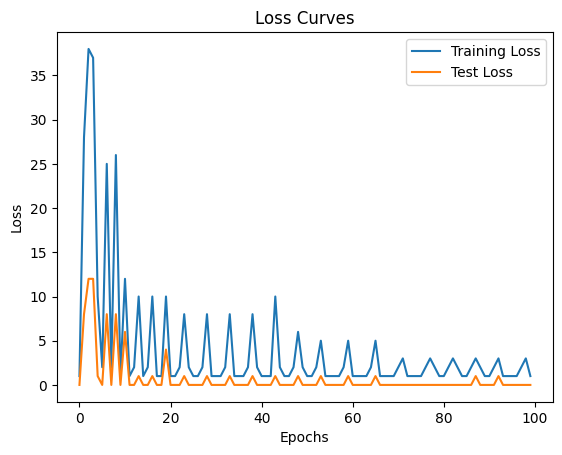

In [20]:
plt.figure()
plt.plot(model.train_loss, label="Training Loss")
plt.plot(model.test_loss, label="Test Loss")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.show()

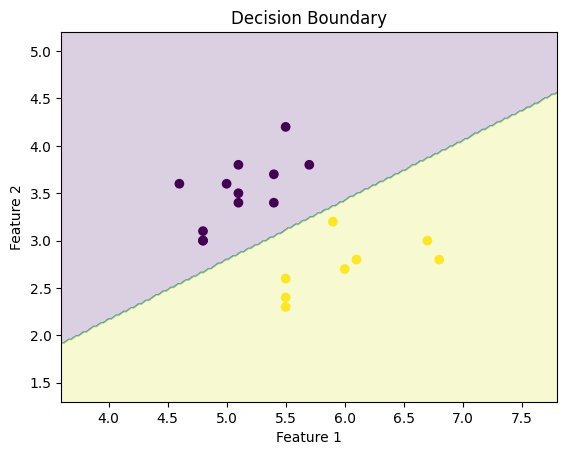

In [12]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.2)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Decision Boundary")
    plt.show()

plot_decision_boundary(model, X_test, y_test)